# DTW Edge Attention Pipeline

Compute edge features between locations from phylogenetic tree tip times.

**Pipeline:** `Tree → Tip times → KDE curves → DTW → (distance, lag_mean, lag_std)`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Add utils to path
notebook_dir = Path(os.getcwd())
utils_dir = notebook_dir.parent / 'utils'

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Import DTW utility functions
from dtw import (
    parse_tree,
    extract_tip_times,
    tips_to_curves,
    dtw_edge_features,
    compute_dtw_matrices
)

print(f"Imports successful!")
print(f"Utils loaded from: {utils_dir}")

Imports successful!
Utils loaded from: /Users/lukelyu/Library/CloudStorage/OneDrive-Emory/emory/phyloGNN/utils


## Core Functions

In [2]:
# Functions are now imported from utils/dtw.py
# Available: parse_tree, extract_tip_times, tips_to_curves, dtw_edge_features, compute_dtw_matrices

In [4]:
# Load tree and compute curves
tree_file = '/Users/lukelyu/Desktop/epidata/40_5_MM0.0025//0_beast2.trees'
tips_by_loc = extract_tip_times(parse_tree(tree_file))
t_grid, curves, dt = tips_to_curves(tips_by_loc)  # Note: tips_to_curves now returns dt as well

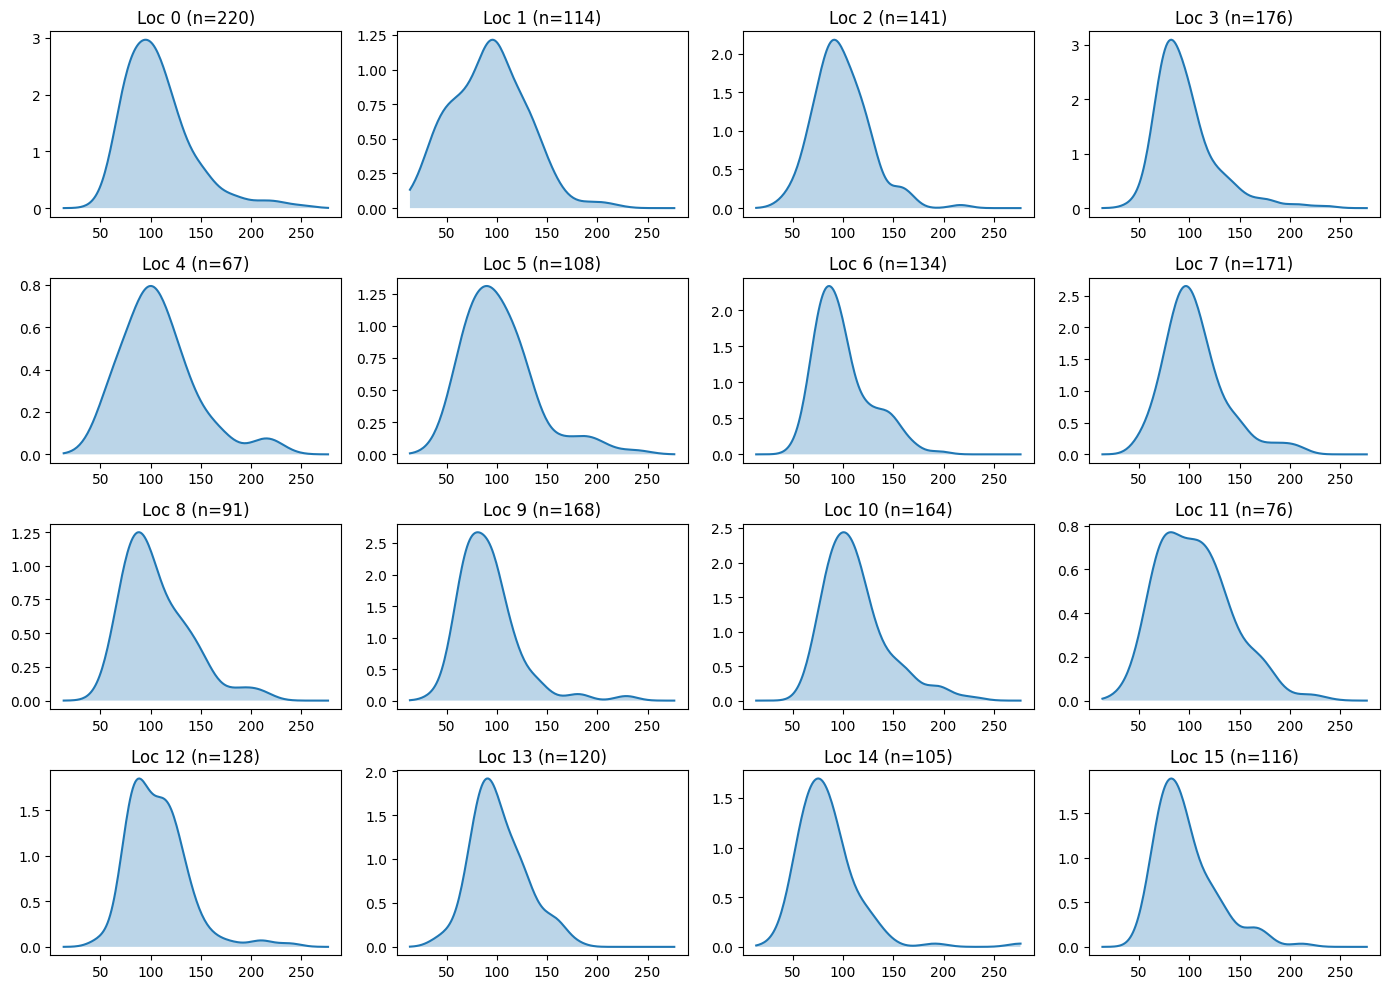

In [5]:
# Plot epidemic curves per location
n_locs = len(curves)
n_cols = 4
n_rows = (n_locs + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.5 * n_rows))
axes = np.atleast_2d(axes)  # Handle single row case

for idx, loc in enumerate(sorted(curves.keys())):
    ax = axes.flat[idx]
    ax.fill_between(t_grid, curves[loc], alpha=0.3)
    ax.plot(t_grid, curves[loc], lw=1.5)
    ax.set_title(f'Loc {loc} (n={len(tips_by_loc[loc])})')

# Hide unused subplots
for idx in range(n_locs, n_rows * n_cols):
    axes.flat[idx].axis('off')

plt.tight_layout()
plt.show()

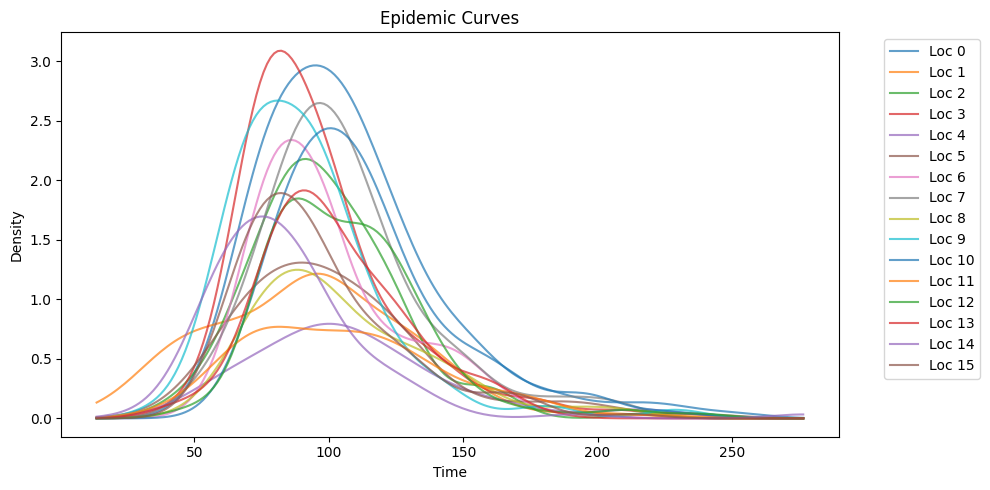

In [6]:
# Overlay all curves
plt.figure(figsize=(10, 5))
for idx, loc in enumerate(sorted(curves.keys())):
    plt.plot(t_grid, curves[loc], lw=1.5, label=f'Loc {loc}', alpha=0.7)
plt.xlabel('Time'), plt.ylabel('Density'), plt.title('Epidemic Curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Compute Edge Features

In [7]:
# Compute edge features using the utility function
dist_mat, lag_mat, lag_std_mat, locations = compute_dtw_matrices(tree_file)

# Sample output
print("Edge Features (i→j): distance, lag_mean, lag_std")
print("-" * 50)
for i in range(min(3, len(locations))):
    for j in range(min(3, len(locations))):
        if i != j:
            print(f"({locations[i]}→{locations[j]}): {dist_mat[i,j]:.2f}, {lag_mat[i,j]:.1f}, {lag_std_mat[i,j]:.1f}")

Edge Features (i→j): distance, lag_mean, lag_std
--------------------------------------------------
(0→1): 84.15, -22.2, 23.7
(0→2): 11.25, -24.3, 24.4
(1→0): 84.15, 22.2, 23.7
(1→2): 18.01, -1.6, 14.5
(2→0): 11.25, 24.3, 24.4
(2→1): 18.01, 1.6, 14.5


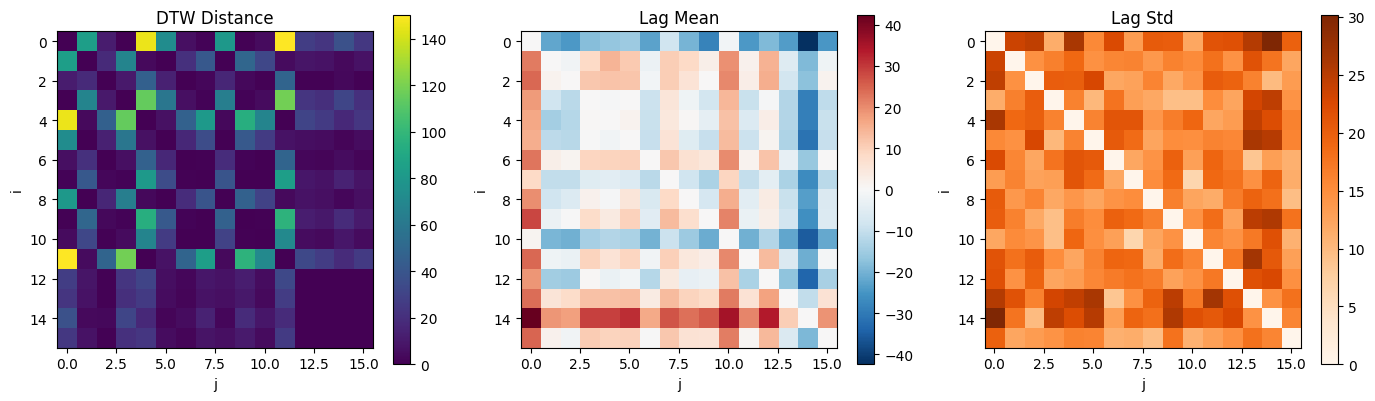

In [8]:
# Visualize as heatmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['DTW Distance', 'Lag Mean', 'Lag Std']
data = [dist_mat, lag_mat, lag_std_mat]
cmaps = ['viridis', 'RdBu_r', 'Oranges']

for ax, d, title, cmap in zip(axes, data, titles, cmaps):
    vmax = np.abs(d).max() if 'Lag Mean' in title else None
    im = ax.imshow(d, cmap=cmap, vmin=-vmax if vmax and 'Mean' in title else None, vmax=vmax)
    ax.set_title(title), ax.set_xlabel('j'), ax.set_ylabel('i')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()